## 1. Import Libraries and Load Cleaned Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, OrdinalEncoder
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Lasso
from xgboost import XGBRegressor

from module_function import cross_validate_model,plot_all_modelsRegression_predictions,evaluate_models_Regression,feature_importance

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('dataset/Housing_prediction_Cleaning.csv')
df_x = df.drop(columns='SalePrice')
df_y = df['SalePrice']

In [4]:
X_train,X_test,y_train,y_test = train_test_split(df_x,df_y,test_size=0.2,random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 480 samples
Test set: 121 samples


## 2.Feature Scaling

In [5]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

base_preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
    ]
)

## 3.Pipleline All Models Regression

In [6]:
regresi_pipelines = {
    'Linear Regression': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=15)),
        ('model', LinearRegression())
    ]),
    
    'Ridge Regression': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=15)),
        ('model', Ridge(alpha=1.0))
    ]),
    
    'Lasso Regression': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=15)),
        ('model', Lasso(alpha=1.0, random_state=42, max_iter=10000))
    ]),
    
    'Random Forest Regressor': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=15)),
        ('model', RandomForestRegressor(random_state=42))
    ]),
    
    'Gradient Boosting Regressor': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=15)),
        ('model', GradientBoostingRegressor(random_state=42))
    ]),
    
    'XGBoost Regressor': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=15)),
        ('model', XGBRegressor(random_state=42, n_estimators=100, learning_rate=0.1))
    ])
}

## 4.Analysis Model Sebelum Cross-Validate

In [7]:
predictions_dict = {}
for model_name, pipeline in regresi_pipelines.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    predictions_dict[model_name] = y_pred

df_report = evaluate_models_Regression( model_dict=predictions_dict, y_test=y_test)
df_report.sort_values(by='R2-Score', ascending=False)

Menguji model: Linear Regression
Menguji model: Ridge Regression
Menguji model: Lasso Regression
Menguji model: Random Forest Regressor
Menguji model: Gradient Boosting Regressor
Menguji model: XGBoost Regressor

Proses Training Selesai!


,Model,R2-Score,MAE,MSE,RMSE
5,XGBoost Regressor,0.9081,14106.0273,3.368451e+08,18353.3400
0,Linear Regression,0.9046,14517.6222,3.496406e+08,18698.6801
2,Lasso Regression,0.9046,14517.9102,3.496441e+08,18698.7714
1,Ridge Regression,0.9043,14535.6489,3.505965e+08,18724.2221
4,Gradient Boosting Regressor,0.9012,14459.2402,3.621776e+08,19030.9655
3,Random Forest Regressor,0.8906,15278.0097,4.011222e+08,20028.0362


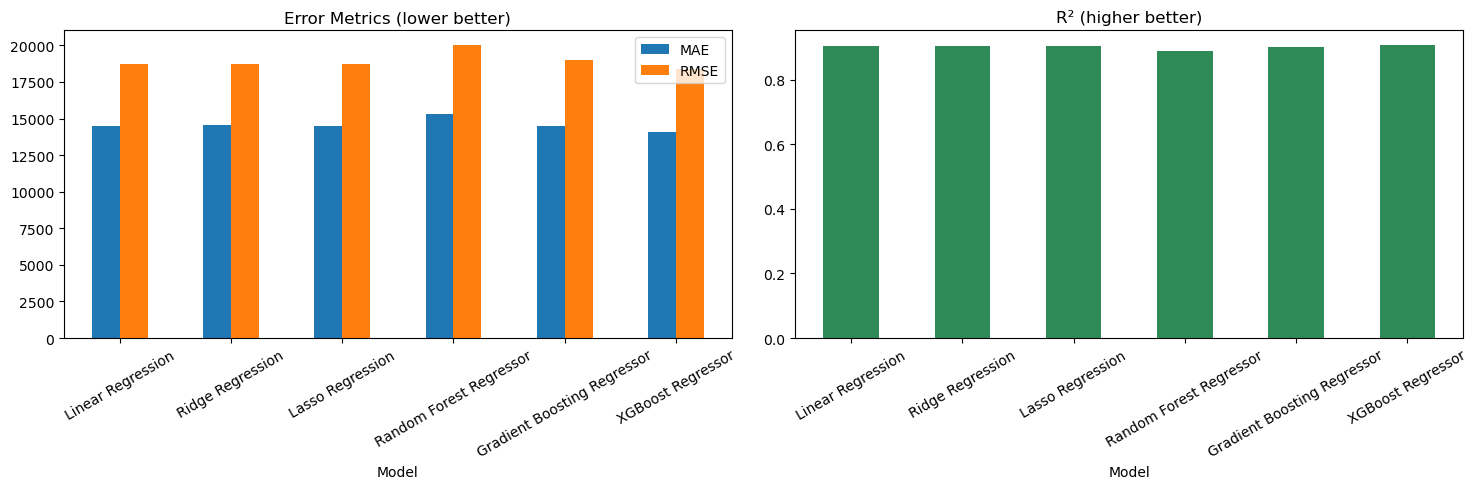

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df_report.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Error Metrics (lower better)')
axes[0].tick_params(axis='x', rotation=30)

df_report.set_index('Model')[['R2-Score']].plot(kind='bar', ax=axes[1], color='seagreen', legend=False)
axes[1].set_title('R² (higher better)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 5.Analysis Model Sesudah Cross-Validate

In [9]:
df_hasil_perbandingan = cross_validate_model(models_dict=regresi_pipelines, X=X_train, y=y_train, cv_folds=5, mode='regression')
df_hasil_perbandingan.sort_values(by='R2-Score', ascending=False)

=== MENJALANKAN 5-FOLD CROSS VALIDATION (REGRESI) ===

Menguji model: Linear Regression
Menguji model: Ridge Regression
Menguji model: Lasso Regression
Menguji model: Random Forest Regressor
Menguji model: Gradient Boosting Regressor
Menguji model: XGBoost Regressor

Proses CV Selesai!


,Model,R2-Score,MAE,MSE,RMSE
4,Gradient Boosting Regressor,0.875514,14817.231984,4.027833e+08,20069.462845
1,Ridge Regression,0.866592,15945.092765,4.325320e+08,20797.403847
2,Lasso Regression,0.866409,15974.065098,4.330969e+08,20810.980172
0,Linear Regression,0.866390,15976.023370,4.331549e+08,20812.374767
3,Random Forest Regressor,0.863273,15253.503801,4.444594e+08,21082.205837
5,XGBoost Regressor,0.851307,16353.236133,4.833502e+08,21985.227040


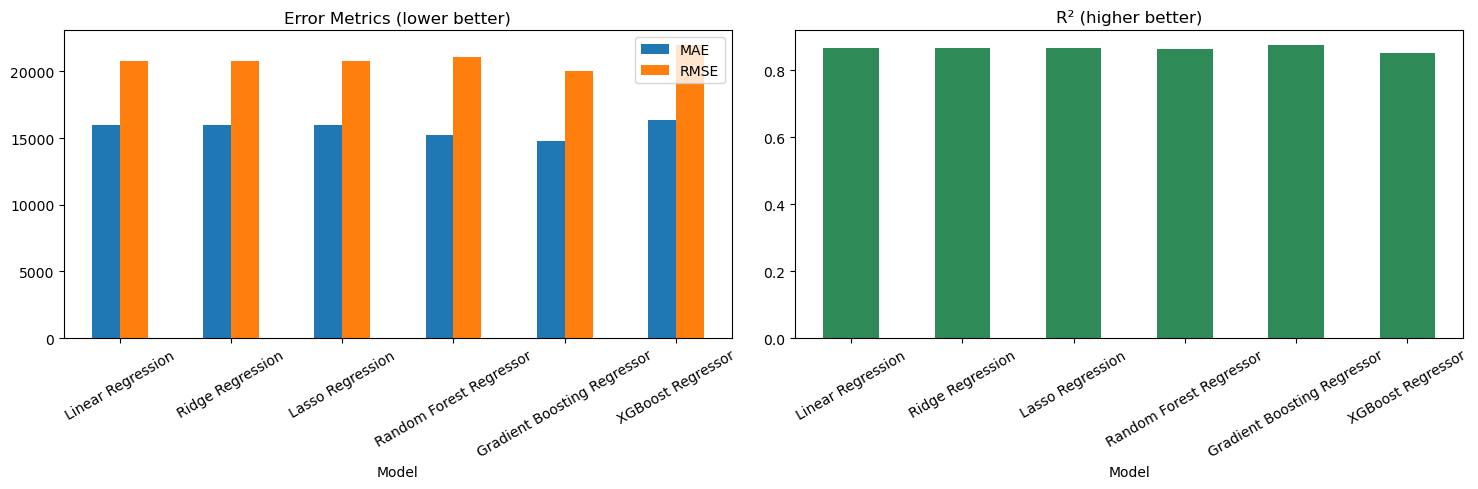

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Grafik 1: MAE dan RMSE (Nama kolom disesuaikan dengan output fungsi)
df_hasil_perbandingan.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Error Metrics (lower better)')
axes[0].tick_params(axis='x', rotation=30)

# Grafik 2: R² Score (Nama kolom disesuaikan dengan output fungsi)
df_hasil_perbandingan.set_index('Model')[['R2-Score']].plot(kind='bar', ax=axes[1], color='seagreen', legend=False)
axes[1].set_title('R² (higher better)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


## 4. Analysis Nilai Asli dan Nilai Prediksi

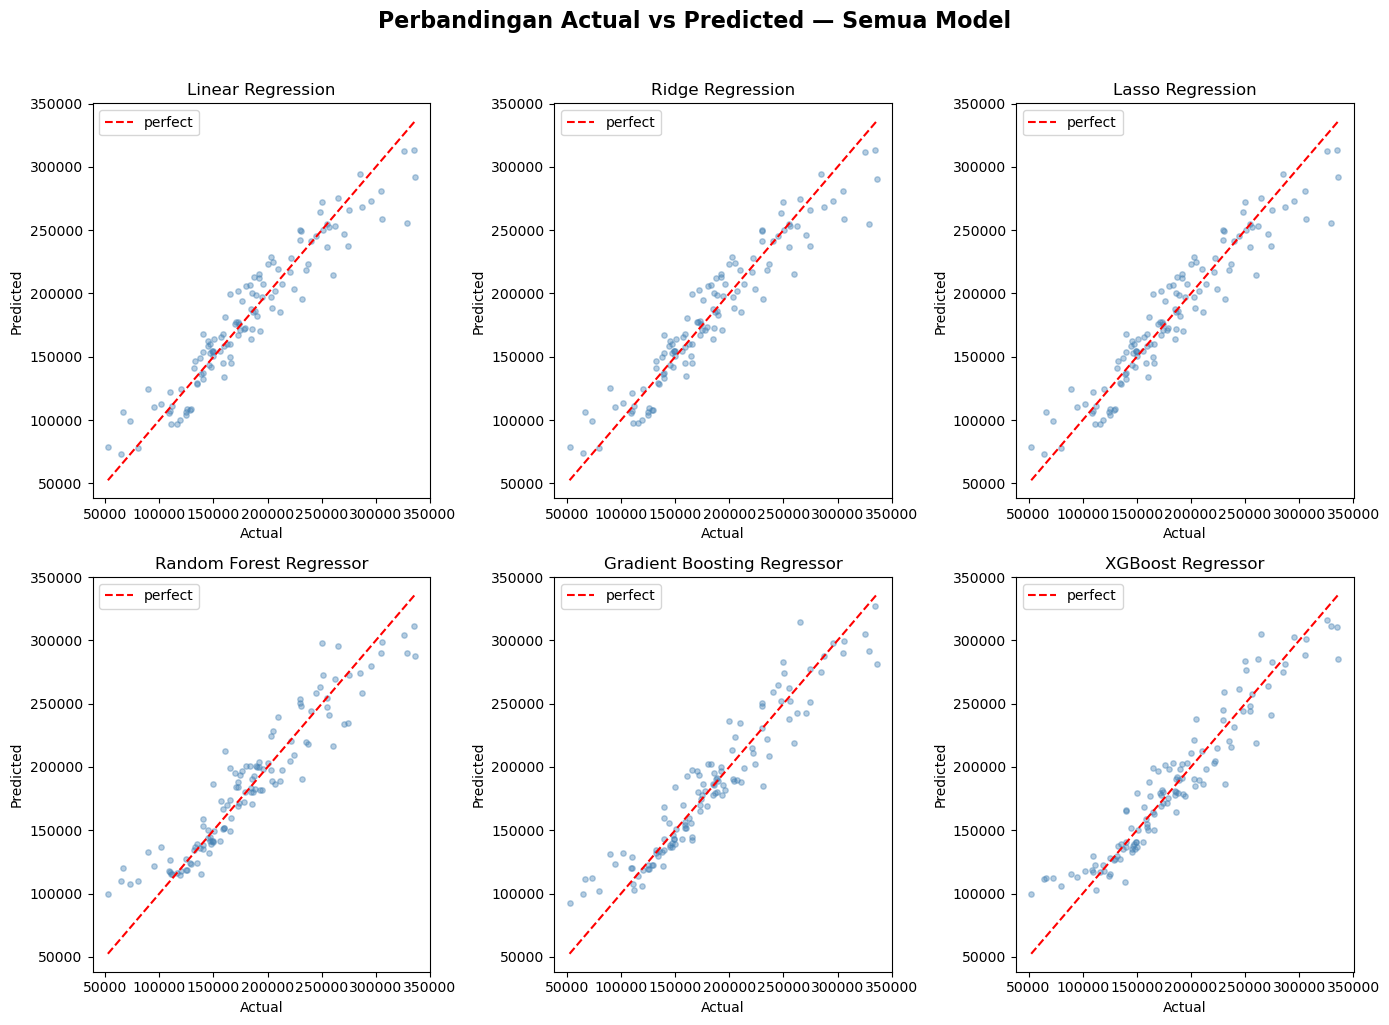

In [11]:
plot_all_modelsRegression_predictions( models_dict=regresi_pipelines, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test,)

## 5. Importance Feature for Models

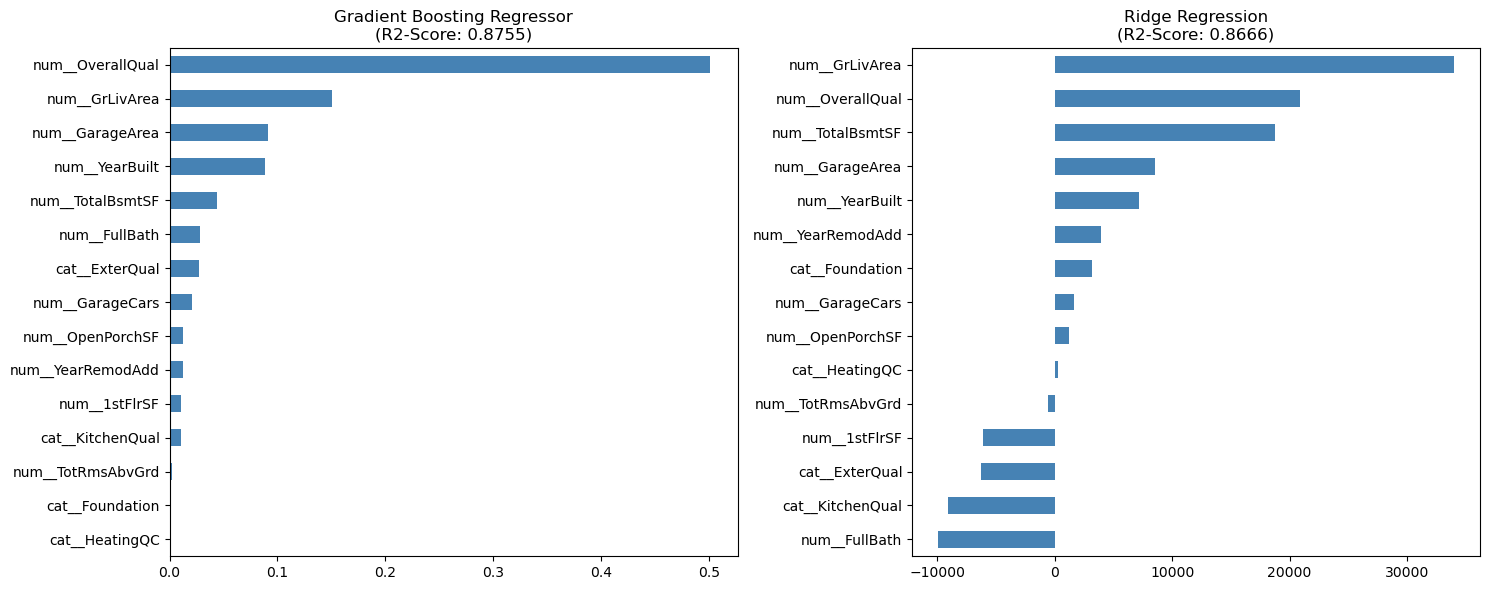

In [12]:
feature_importance(result_crossValidate=df_hasil_perbandingan,model_dict=regresi_pipelines)